In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/kaggle/input/datasets/asifxzaman/social-media-addiction-vs-productivity-dataset/social_media_productivity_6000.csv')

print(data.head(5))

    age  daily_screen_time  social_media_hours  study_hours  sleep_hours  \
0  21.0               5.95                2.81         2.61         6.99   
1  34.0               3.82                2.33         0.28         7.47   
2  29.0               3.57                1.64         5.21         6.34   
3  25.0              10.27                4.37         4.28         4.49   
4  22.0               2.42                1.60         3.67         6.34   

   notifications_per_day  focus_score addiction_level  productivity_score  
0                  283.0       100.00          Medium               28.49  
1                  266.0        93.65          Medium               18.54  
2                  137.0       100.00             Low               68.52  
3                  247.0        94.71          Medium               27.82  
4                   28.0       100.00             Low               51.09  


In [3]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB
None
               age  daily_screen_time  social_media_hours  study_hours  \
count  5880.000000        5880.000000         5880.000000  5880.000000   
mean     27.111395           6.923175            4.145915     4.069328   
std       7.268430           2.859055    

In [4]:
print(data.isna().sum())

age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64


In [5]:
missing_percent = (data.isna().sum() / len(data)) * 100
print(missing_percent)

age                      2.0
daily_screen_time        2.0
social_media_hours       2.0
study_hours              2.0
sleep_hours              2.0
notifications_per_day    2.0
focus_score              2.0
addiction_level          2.0
productivity_score       2.0
dtype: float64


In [6]:
data = data.dropna()

In [7]:
print(data.isna().sum())

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64


In [8]:
print(data.shape)

(4999, 9)


In [9]:
print(data.duplicated().sum())

0


In [10]:
print(data.head(5))

    age  daily_screen_time  social_media_hours  study_hours  sleep_hours  \
0  21.0               5.95                2.81         2.61         6.99   
1  34.0               3.82                2.33         0.28         7.47   
2  29.0               3.57                1.64         5.21         6.34   
3  25.0              10.27                4.37         4.28         4.49   
4  22.0               2.42                1.60         3.67         6.34   

   notifications_per_day  focus_score addiction_level  productivity_score  
0                  283.0       100.00          Medium               28.49  
1                  266.0        93.65          Medium               18.54  
2                  137.0       100.00             Low               68.52  
3                  247.0        94.71          Medium               27.82  
4                   28.0       100.00             Low               51.09  


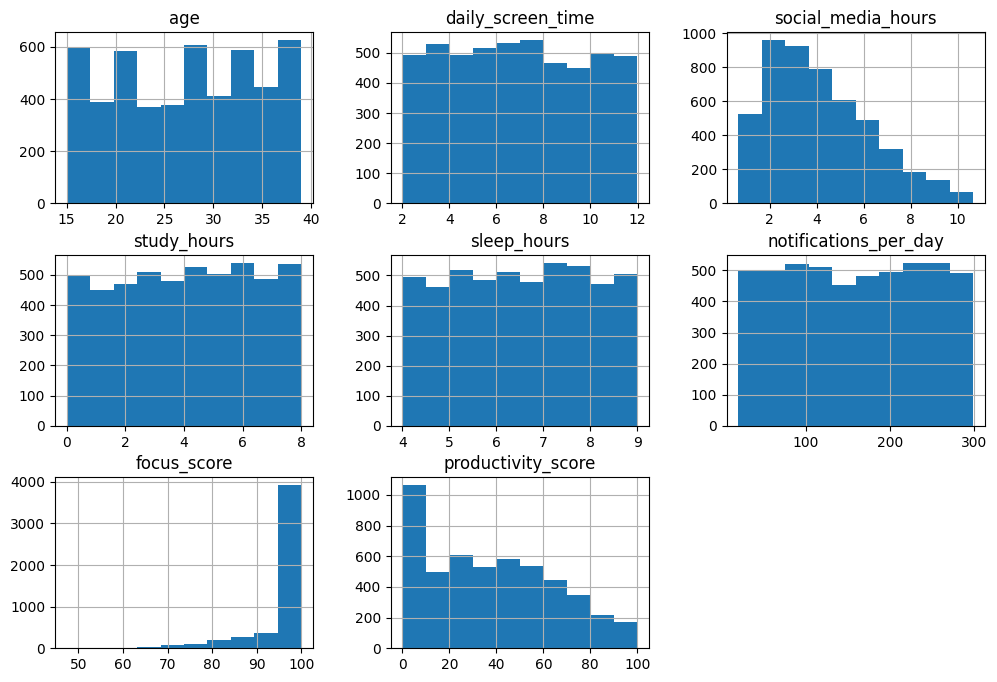

In [11]:
data.hist(figsize=(12,8))
plt.show()

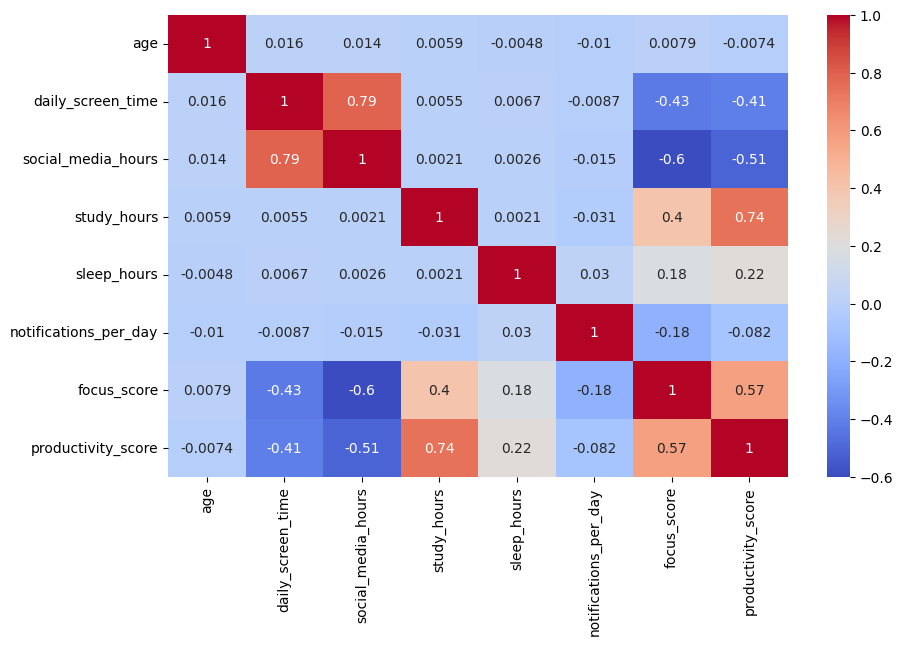

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [13]:
print(data['addiction_level'].value_counts())

addiction_level
Medium    2605
High      1585
Low        809
Name: count, dtype: int64


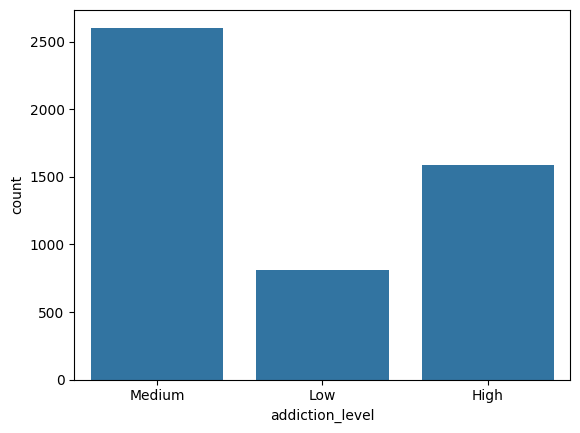

In [14]:
sns.countplot(x='addiction_level', data=data)
plt.show()

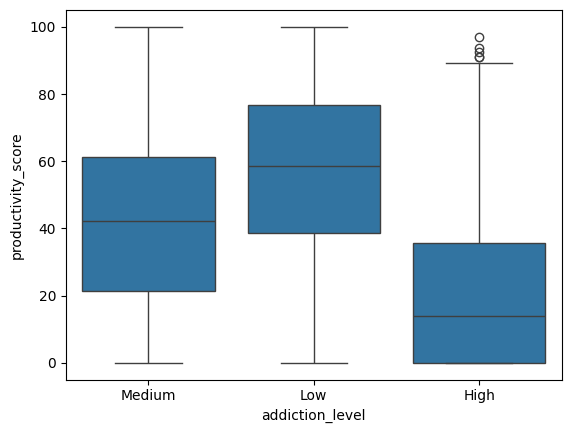

In [15]:
sns.boxplot(x='addiction_level', y='productivity_score', data=data)
plt.show()

In [16]:
print(data.groupby('addiction_level')['productivity_score'].mean())

addiction_level
High      20.411798
Low       57.295847
Medium    42.216004
Name: productivity_score, dtype: float64


In [17]:
print(data.columns)

Index(['age', 'daily_screen_time', 'social_media_hours', 'study_hours',
       'sleep_hours', 'notifications_per_day', 'focus_score',
       'addiction_level', 'productivity_score'],
      dtype='object')


In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [25]:
# Pilih fitur untuk clustering (Perilaku vs Hasil)
features_for_clustering = ['social_media_hours', 'study_hours', 'sleep_hours', 'productivity_score', 'notifications_per_day']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[features_for_clustering])

# Kita buat 4 cluster (Persona)
kmeans = KMeans(n_clusters=4, random_state=42)
data['persona'] = kmeans.fit_predict(scaled_features)

# Beri nama Persona berdasarkan karakteristik rata-rata
persona_summary = data.groupby('persona')[features_for_clustering].mean()
print(persona_summary)

         social_media_hours  study_hours  sleep_hours  productivity_score  \
persona                                                                     
0                  3.177198     1.728347     6.510867           20.021848   
1                  3.363284     5.775947     7.810311           66.624363   
2                  7.245675     3.484426     6.330129           11.011570   
3                  3.335573     5.802302     5.206984           53.863704   

         notifications_per_day  
persona                         
0                   169.922043  
1                   160.746894  
2                   160.135904  
3                   144.695767  


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

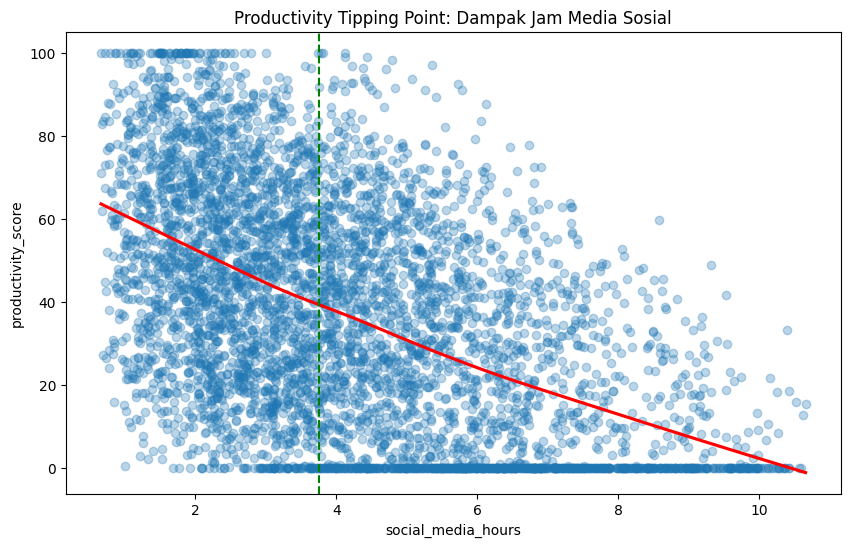

In [21]:
plt.figure(figsize=(10, 6))
sns.regplot(data=data, x='social_media_hours', y='productivity_score', lowess=True, 
            line_kws={'color': 'red'}, scatter_kws={'alpha': 0.3})
plt.title('Productivity Tipping Point: Dampak Jam Media Sosial')
plt.axvline(x=data['social_media_hours'].median(), color='green', linestyle='--', label='Median Usage')
plt.show()

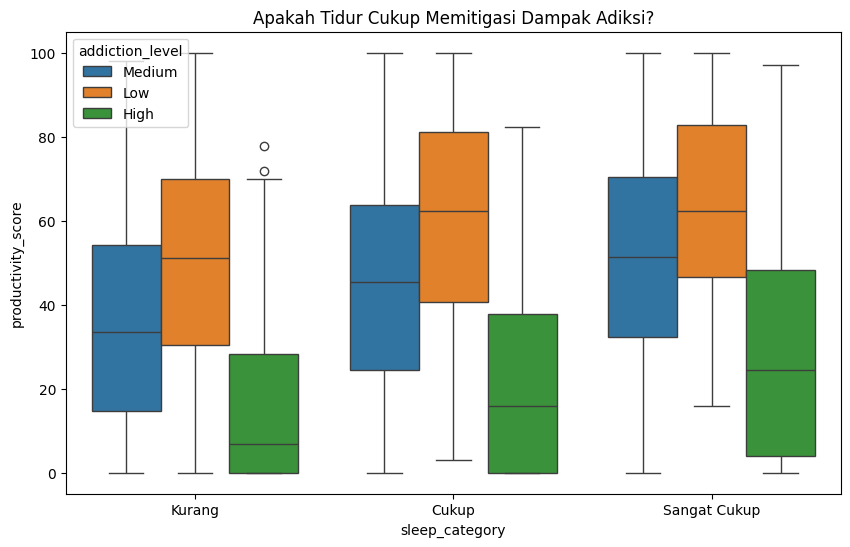

In [22]:
# Membuat kategori tidur
data['sleep_category'] = pd.cut(data['sleep_hours'], bins=[0, 6, 8, 12], labels=['Kurang', 'Cukup', 'Sangat Cukup'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='sleep_category', y='productivity_score', hue='addiction_level')
plt.title('Apakah Tidur Cukup Memitigasi Dampak Adiksi?')
plt.show()

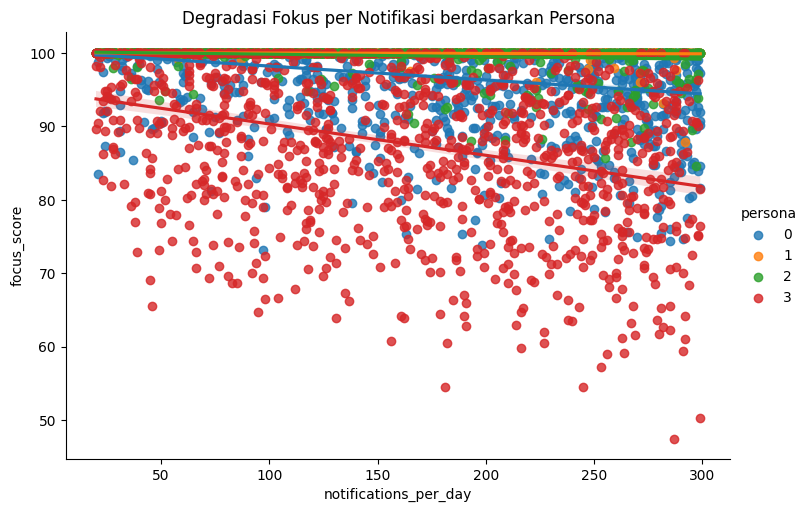

In [23]:
data['focus_per_notification'] = data['focus_score'] / (data['notifications_per_day'] + 1)

sns.lmplot(data=data, x='notifications_per_day', y='focus_score', hue='persona', aspect=1.5)
plt.title('Degradasi Fokus per Notifikasi berdasarkan Persona')
plt.show()

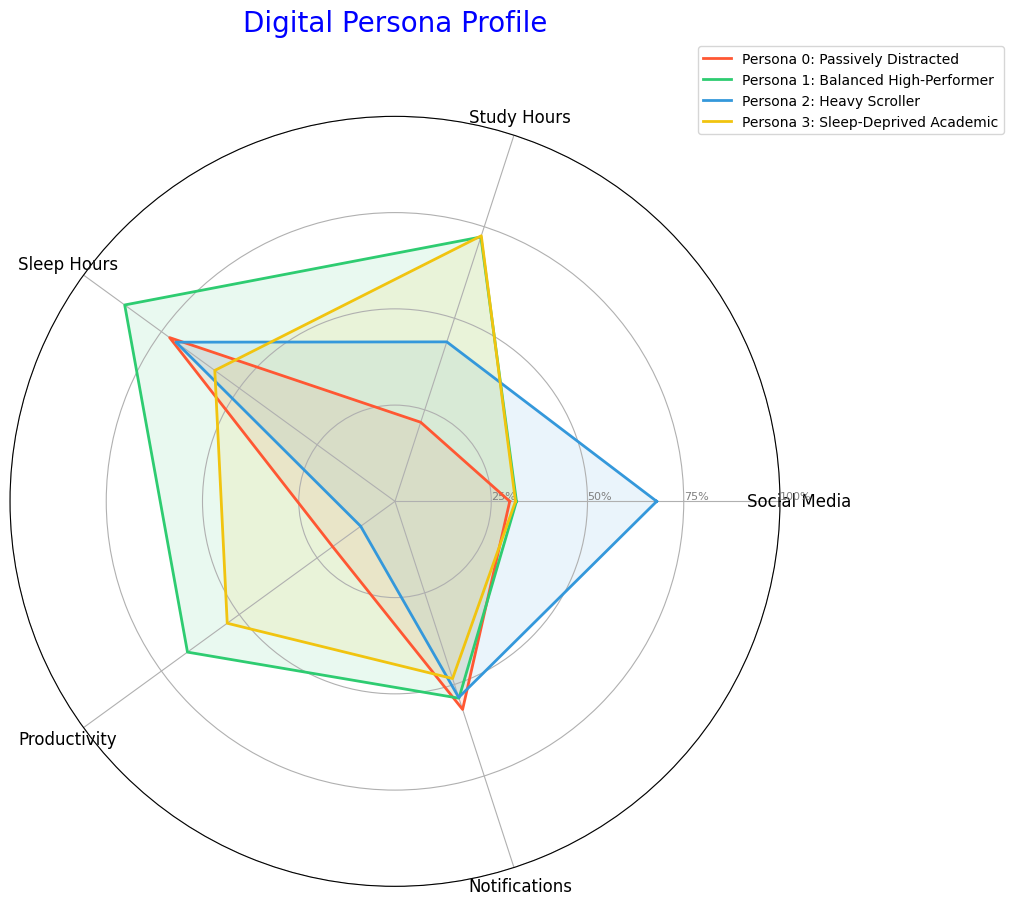

In [31]:
# 1. Tentukan fitur yang ingin ditampilkan di Radar Chart
features = ['social_media_hours', 'study_hours', 'sleep_hours', 'productivity_score', 'notifications_per_day']
labels = ['Social Media', 'Study Hours', 'Sleep Hours', 'Productivity', 'Notifications']

# 2. Calculate means for every persona
persona_means = data.groupby('persona')[features].mean()

# 3. Normalization (Skala 0-1) berdasarkan nilai maksimum di dataset 
persona_norm = persona_means / data[features].max()

# 4. Setting Radar Chart
N = len(features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Menutup loop

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

colors = ['#FF5733', '#2ECC71', '#3498DB', '#F1C40F'] 
persona_names = {
    0: "Persona 0: Passively Distracted",
    1: "Persona 1: Balanced High-Performer",
    2: "Persona 2: Heavy Scroller",
    3: "Persona 3: Sleep-Deprived Academic"
}

# 5. Plotting every clusters 
for i, (idx, row) in enumerate(persona_norm.iterrows()):
    values = row.tolist()
    values += values[:1] # Menutup loop
    
    name = persona_names.get(idx, f"Persona {idx}")
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=name, color=colors[i % len(colors)])
    ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.1)

plt.xticks(angles[:-1], labels, color='black', size=12)
ax.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75, 1.0], ["25%", "50%", "75%", "100%"], color="grey", size=8)
plt.ylim(0, 1)

plt.title('Digital Persona Profile', size=20, color='blue', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

In [33]:
from scipy import stats

# Memisahkan data skor produktivitas untuk masing-masing persona
p0 = data[data['persona'] == 0]['productivity_score']
p1 = data[data['persona'] == 1]['productivity_score']
p2 = data[data['persona'] == 2]['productivity_score']
p3 = data[data['persona'] == 3]['productivity_score']

# Melakukan One-Way ANOVA
f_stat, p_val = stats.f_oneway(p0, p1, p2, p3)

print(f"Hasil ANOVA:")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("\nKesimpulan: Signifikan! Setidaknya ada satu persona yang memiliki tingkat produktivitas yang berbeda secara nyata.")
else:
    print("\nKesimpulan: Tidak Signifikan. Tidak ada perbedaan nyata antar persona.")

Hasil ANOVA:
F-Statistic: 3626.2217
P-Value: 0.0000e+00

Kesimpulan: Signifikan! Setidaknya ada satu persona yang memiliki tingkat produktivitas yang berbeda secara nyata.



Hasil Uji Lanjut (Tukey HSD):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     0      1  46.6025   0.0  45.0863  48.1188   True
     0      2  -9.0103   0.0 -10.5991  -7.4215   True
     0      3  33.8419   0.0  32.2714  35.4123   True
     1      2 -55.6128   0.0 -57.2529 -53.9727   True
     1      3 -12.7607   0.0  -14.383 -11.1383   True
     2      3  42.8521   0.0  41.1618  44.5425   True
-----------------------------------------------------


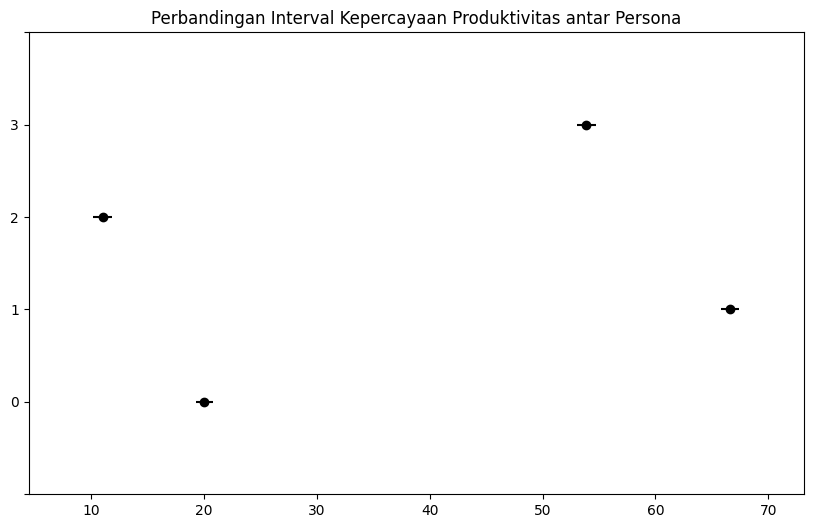

In [34]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Melakukan Tukey HSD
tukey = pairwise_tukeyhsd(endog=data['productivity_score'], 
                          groups=data['persona'], 
                          alpha=0.05)

print("\nHasil Uji Lanjut (Tukey HSD):")
print(tukey)

# Visualisasi perbedaan rata-rata
tukey.plot_simultaneous()
plt.title("Perbandingan Interval Kepercayaan Produktivitas antar Persona")
plt.show()

In [35]:
# Membandingkan Persona 1 dan Persona 3
t_stat, t_pval = stats.ttest_ind(p1, p3)

print(f"\nT-Test Persona 1 vs Persona 3:")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {t_pval:.4e}")


T-Test Persona 1 vs Persona 3:
T-Statistic: 18.3558
P-Value: 1.4643e-70


In [37]:
# Membandingkan Persona 0 dan Persona 2
t_stat, t_pval = stats.ttest_ind(p0, p2)

print(f"\nT-Test Persona 0 vs Persona 2:")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {t_pval:.4e}")


T-Test Persona 0 vs Persona 2:
T-Statistic: 16.2931
P-Value: 7.0175e-57
